# `summaryMetrics` Reliability Validation

Compare last-epoch metric values from the W&B GraphQL `summaryMetrics` field against true best-epoch values from `wandb/summary.parquet`.

**Question:** How much does the last-epoch value of `epoch/test_recall@20` differ from the best-epoch value (`best:epoch/test_recall@20`)?

**Decision:** If the gap is small and unbiased on average → proceed with `summaryMetrics`. If there is systematic downward bias (e.g. degraded runs pulling targets down) → switch to reading the parquet file.


In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.figure import Figure
from matplotlib.axes import Axes
from typing import List
from src.utils.config import fetch_experiment_runs
from src.visualization import set_themes

set_themes()

TARGET_METRIC = "epoch/test_recall@20"   # key in summaryMetrics (last-epoch)
PARQUET_TARGET = "best:epoch/test_recall@20"  # key in wandb/summary.parquet (best-epoch)
PARQUET_PATH = "wandb/summary.parquet"


## Load Data

### Source A — `summaryMetrics` via GraphQL (last epoch)

In [2]:
live_runs = fetch_experiment_runs(
    {"config.model": "matrix_factorization", "state": "finished"},
    include_summary_metrics=True,
)

print(f"Fetched {len(live_runs):,} finished runs from GraphQL")
print(f"Columns with epoch/ prefix: {[c for c in live_runs.columns if c.startswith('epoch/')][:5]} ...")
live_runs.head(3)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Fetched 256 runs...
Fetched 512 runs...
Fetched 768 runs...
Fetched 1024 runs...
Fetched 1280 runs...
Fetched 1536 runs...
Fetched 1792 runs...
Fetched 2048 runs...
Fetched 2304 runs...
Fetched 2560 runs...
Fetched 2816 runs...
Fetched 3072 runs...
Fetched 3328 runs...
Fetched 3390 runs...
Fetched 3,390 finished runs from GraphQL
Columns with epoch/ prefix: ['epoch/epoch', 'epoch/learning_rate', 'epoch/step_delta', 'epoch/test_hitrate@10', 'epoch/test_hitrate@2'] ...


node_id,run_id,run_name,model,config,shuffle,tracker,log_freq,max_epoch,batch_size,random_seed,store_model,learning_rate,early_stopping,l1_regularization,l2_regularization,evaluation_cutoffs,early_stopping_mode,embedding_dimension,early_stopping_monitor,embedding_dropout_rate,early_stopping_patience,runtime,step,timestamp,epoch/epoch,epoch/learning_rate,epoch/step_delta,epoch/test_hitrate@10,epoch/test_hitrate@2,epoch/test_hitrate@20,epoch/test_hitrate@50,epoch/test_loss,epoch/test_map@10,epoch/test_map@2,epoch/test_map@20,epoch/test_map@50,…,epoch/test_ndcg@2,epoch/test_ndcg@20,epoch/test_ndcg@50,epoch/test_precision@10,epoch/test_precision@2,epoch/test_precision@20,epoch/test_precision@50,epoch/test_recall@10,epoch/test_recall@2,epoch/test_recall@20,epoch/test_recall@50,epoch/train_hitrate@10,epoch/train_hitrate@2,epoch/train_hitrate@20,epoch/train_hitrate@50,epoch/train_loss,epoch/train_map@10,epoch/train_map@2,epoch/train_map@20,epoch/train_map@50,epoch/train_mrr@10,epoch/train_mrr@2,epoch/train_mrr@20,epoch/train_mrr@50,epoch/train_ndcg@10,epoch/train_ndcg@2,epoch/train_ndcg@20,epoch/train_ndcg@50,epoch/train_precision@10,epoch/train_precision@2,epoch/train_precision@20,epoch/train_precision@50,epoch/train_recall@10,epoch/train_recall@2,epoch/train_recall@20,epoch/train_recall@50,config_collapse_method
str,str,str,str,str,bool,str,str,i64,i64,i64,bool,f64,bool,f64,f64,list[i64],str,i64,str,f64,i64,i64,i64,f64,i64,f64,i64,f64,f64,f64,f64,str,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""UnVuOnYxOjhrdnhvZGNqOnBlcHBlcm…","""8kvxodcj""","""fallen-valley-6062""","""matrix_factorization""","""configs/hyperparameter_search/…",false,"""wandb""","""epoch""",64,16384,3946,false,0.01,false,0.0,0.0,"[2, 10, … 50]","""max""",256,"""test_recall@10""",0.9,0,928,63,1.7746e9,63,0.01,8459,0.01121,0.00281,0.02763,0.03363,"""NaN""",0.002542,0.001405,0.003591,0.003774,…,0.001773,0.008623,0.009818,0.001159,0.001405,0.001483,0.000724,0.001259,0.000319,0.003466,0.004097,0.05324,0.018189,0.113774,0.134647,"""NaN""",0.01355,0.009094,0.017134,0.017881,0.013946,0.009094,0.018102,0.018781,0.022908,0.011476,0.038741,0.043305,0.006126,0.009094,0.007868,0.00387,0.00184,0.000607,0.004774,0.005643,null
"""UnVuOnYxOnR6YzEzcnB0OnBlcHBlcm…","""tzc13rpt""","""comfy-aardvark-6061""","""matrix_factorization""","""configs/hyperparameter_search/…",true,"""wandb""","""epoch""",64,16384,12761,false,0.01,false,0.0,0.0,"[2, 10, … 50]","""max""",256,"""test_recall@10""",0.9,0,1088,63,1.7746e9,63,0.01,8459,0.01121,0.00281,0.02763,0.03363,"""NaN""",0.002542,0.001405,0.003591,0.003774,…,0.001773,0.008623,0.009818,0.001159,0.001405,0.001483,0.000724,0.001259,0.000319,0.003466,0.004097,0.05324,0.018189,0.113774,0.134647,"""NaN""",0.01355,0.009094,0.017134,0.017881,0.013946,0.009094,0.018102,0.018781,0.022908,0.011476,0.038741,0.043305,0.006126,0.009094,0.007868,0.00387,0.00184,0.000607,0.004774,0.005643,null
"""UnVuOnYxOms2bXp0NmthOnBlcHBlcm…","""k6mzt6ka""","""grateful-sun-6060""","""matrix_factorization""","""configs/hyperparameter_search/…",false,"""wandb""","""epoch""",64,16384,12428,false,0.01,false,0.0,0.0,"[2, 10, … 50]","""max""",256,"""test_recall@10""",0.8,0,966,63,1.7746e9,63,0.01,8459,0.01121,0.00281,0.02763,0.03363,"""NaN""",0.002542,0.001405,0.003591,0.003774,…,0.001773,0.008623,0.009818,0.001159,0.001405,0.001483,0.000724,0.001259,0.000319,0.003466,0.004097,0.05324,0.018189,0.113774,0.134647,"""NaN""",0.01355,0.009094,0.017134,0.017881,0.013946,0.009094,0.018102,0.018781,0.022908,0.011476,0.038741,0.043305,0.006126,0.009094,0.007868,0.00387,0.00184,0.000607,0.004774,0.005643,null


### Source B — `wandb/summary.parquet` (best epoch)

In [17]:
parquet_runs = pl.read_parquet(PARQUET_PATH).filter(pl.col("model") == "matrix_factorization")

print(f"Loaded {len(parquet_runs):,} runs from parquet")
print(f"Parquet target column present: {PARQUET_TARGET in parquet_runs.columns}")
recall_20 = parquet_runs[PARQUET_TARGET].to_numpy()

print(f"Recall@20:")
print(f"  min:    {recall_20.min():.6f}")
print(f"  mean:   {recall_20.mean():.6f}")
print(f"  median: {np.median(recall_20):.6f}")
print(f"  std:    {recall_20.std():.6f}")
print(f"  max:    {recall_20.max():.6f}")
print(f"  p95:    {np.percentile(recall_20, 95):.6f}")

parquet_runs.head(3)

Loaded 3,390 runs from parquet
Parquet target column present: True
Recall@20:
  min:    0.000344
  mean:   0.021562
  median: 0.025306
  std:    0.019223
  max:    0.050881
  p95:    0.045661


run_id,run_name,sweep_id,model,created_at,config,shuffle,tracker,log_freq,max_epoch,batch_size,random_seed,store_model,learning_rate,early_stopping,l1_regularization,l2_regularization,evaluation_cutoffs,early_stopping_mode,embedding_dimension,early_stopping_monitor,embedding_dropout_rate,early_stopping_patience,epoch/test_hitrate@50,epoch/train_map@2,epoch/learning_rate,epoch/train_mrr@50,epoch/test_map@10,epoch/train_precision@20,epoch/train_mrr@20,epoch/train_ndcg@2,epoch/train_precision@50,epoch/train_recall@20,epoch/train_ndcg@20,epoch/test_hitrate@10,epoch/test_ndcg@2,epoch/test_mrr@2,…,best:epoch/test_precision@10,best:epoch/test_map@50,best:_timestamp,best:epoch/train_hitrate@50,best:epoch/test_precision@50,best:epoch/test_map@20,best:epoch/train_precision@2,best:epoch/train_recall@2,best:epoch/test_hitrate@20,best:epoch/train_map@50,best:epoch/test_loss,best:epoch/test_recall@50,best:epoch/test_mrr@50,best:epoch/train_hitrate@10,best:epoch/test_ndcg@10,best:epoch/test_recall@10,best:epoch/train_mrr@2,best:epoch/epoch,best:_step,best:epoch/train_ndcg@50,best:epoch/train_recall@10,best:epoch/train_precision@10,best:epoch/test_recall@20,best:epoch/train_loss,best:epoch/test_map@2,best:_runtime,best:epoch/train_hitrate@20,best:epoch/test_mrr@20,best:epoch/test_hitrate@2,best:epoch/test_precision@20,best:score,gpu_type,cpu_count,config_collapse_method,available_locally,run_duration_second,run_duration_minute
str,str,str,str,datetime[μs],str,bool,str,str,i64,i64,i64,bool,f64,bool,f64,f64,str,str,i64,str,f64,i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,bool,f64,f64
"""o94q0juk""","""logical-sweep-1""","""nbysw136""","""matrix_factorization""",2026-01-24 16:14:22,null,false,"""wandb""","""epoch""",64,16384,3060,false,0.01,false,0.0,0.000001,"""[2, 10, 20, 50]""","""max""",256,"""test_recall@10""",0.0,0,"[0.263136, 0.408583, … 0.473633]","[0.740779, 0.235364, … 0.218091]","[0.01, 0.01, … 0.01]","[0.780483, 0.312187, … 0.305071]","[0.033887, 0.060694, … 0.070892]","[0.248588, 0.093283, … 0.105239]","[0.780023, 0.307271, … 0.300201]","[0.757516, 0.24658, … 0.231309]","[0.15519, 0.071562, … 0.083504]","[0.177492, 0.054866, … 0.061336]","[0.75293, 0.377263, … 0.389264]","[0.097827, 0.167646, … 0.197171]","[0.022828, 0.044407, … 0.050903]","[0.021315, 0.041509, … 0.047509]",…,0.024372,0.068202,1.7693e9,0.905425,0.016513,0.072167,0.157446,0.009601,0.303177,0.194804,0.372714,0.087086,0.085133,0.61109,0.100539,0.026077,0.223191,52.0,52.0,0.413116,0.035844,0.120885,0.045531,0.330564,0.045977,687.748114,0.759979,0.079768,0.059145,0.021315,0.303177,"""NVIDIA A10G""",8,null,false,812.122821,13.53538
"""4ftaae0p""","""stilted-sweep-3""","""nbysw136""","""matrix_factorization""",2026-01-24 16:14:22,null,false,"""wandb""","""epoch""",64,16384,3015,false,0.01,false,0.0,0.00001,"""[2, 10, 20, 50]""","""max""",4,"""test_recall@10""",0.0,0,"[0.074334, 0.061324, … 0.113111]","[0.027125, 0.016168, … 0.03442]","[0.01, 0.01, … 0.01]","[0.048825, 0.031517, … 0.058576]","[0.007757, 0.005603, … 0.011915]","[0.010443, 0.008216, … 0.015171]","[0.045177, 0.028701, … 0.055429]","[0.029085, 0.017268, … 0.037157]","[0.008214, 0.00695, … 0.012427]","[0.006306, 0.004722, … 0.00871]","[0.070954, 0.047835, … 0.08368]","[0.022167, 0.016168, … 0.03723]","[0.00521, 0.003788, … 0.007155]","[0.004784, 0.003552, … 0.006568]",…,0.005709,0.019312,1.7693e9,0.326955,0.003801,0.019029,0.031325,0.002029,0.077713,0.052856,0.693148,0.021158,0.022247,0.157793,0.02556,0.006594,0.044998,59.0,59.0,0.120245,0.007561,0.023999,0.010721,0.693148,0.011778,775.058351,0.221517,0.020355,0.014715,0.004748,0.077713,"""NVIDIA A10G""",8,null,false,819.567704,13.659462
"""fway5u2z""","""breezy-sweep-4""","""nbysw136""","""matrix_factorization""",2026-01-24 16:1

## Join on run ID

Inner join — only runs present in both sources. Runs in the parquet but not in the live fetch (or vice versa) are dropped for the comparison.

In [18]:
live_subset = live_runs.select(["run_id", "embedding_dimension", "l1_regularization", "l2_regularization", "shuffle", TARGET_METRIC]).rename({TARGET_METRIC: "last_epoch"})

# summaryMetrics string values like 'NaN' won't auto-cast — coerce to float, invalid → null
live_subset = live_subset.with_columns(
    pl.col("last_epoch").cast(pl.Float64, strict=False)
)

parquet_subset = parquet_runs.select(["run_id", PARQUET_TARGET]).rename(
    {PARQUET_TARGET: "best_epoch"}
)

combined_runs = live_subset.join(parquet_subset, on="run_id", how="inner")

print(f"Matched runs: {len(combined_runs):,}")
print(f"  last_epoch nulls:  {combined_runs['last_epoch'].null_count():,}  ({100 * combined_runs['last_epoch'].null_count() / len(combined_runs):.1f}%)")
print(f"  best_epoch nulls:  {combined_runs['best_epoch'].null_count():,}  ({100 * combined_runs['best_epoch'].null_count() / len(combined_runs):.1f}%)")

combined_runs = combined_runs.drop_nulls()
combined_runs = combined_runs.with_columns((pl.col("best_epoch") - pl.col("last_epoch")).alias("gap"))

# Drop runs with negative gap (artifact of composite sorting criterion — parquet best epoch
# was selected to maximise a different metric, so recall@20 there may be below the last epoch)
n_negative = (combined_runs["gap"] < 0).sum()
combined_runs = combined_runs.filter(pl.col("gap") >= 0)
print(f"  Dropped {n_negative:,} runs with negative gap")

combined_runs


Matched runs: 3,390
  last_epoch nulls:  0  (0.0%)
  best_epoch nulls:  0  (0.0%)
  Dropped 128 runs with negative gap


run_id,embedding_dimension,l1_regularization,l2_regularization,shuffle,last_epoch,best_epoch,gap
str,i64,f64,f64,bool,f64,f64,f64
"""o94q0juk""",256,0.0,0.000001,false,0.044344,0.045531,0.001187
"""4ftaae0p""",4,0.0,0.00001,false,0.007478,0.010721,0.003243
"""fway5u2z""",512,0.0,0.0001,false,0.003466,0.004331,0.000866
"""bphcl2xf""",1024,0.0,0.0,false,0.030755,0.042439,0.011684
"""dcbj92eg""",256,0.0,1.0000e-8,false,0.033998,0.042344,0.008347
…,…,…,…,…,…,…,…
"""mf782na5""",256,0.0,0.0,false,0.003466,0.039559,0.036093
"""mp5e1j68""",256,0.0,0.0,true,0.003466,0.034741,0.031275
"""k6mzt6ka""",256,0.0,0.0,false,0.003466,0.034422,0.030957


## Gap Analysis

Compute `gap = best_epoch - last_epoch`. A positive gap means the run peaked before the final epoch (loss explosion or overfitting). A zero gap means last epoch == best epoch.

In [19]:
gap = combined_runs["gap"].to_numpy()
last = combined_runs["last_epoch"].to_numpy()
best = combined_runs["best_epoch"].to_numpy()

print(f"Gap (best - last):")
print(f"  min:   {gap.min():.6f}")
print(f"  mean:   {gap.mean():.6f}")
print(f"  median: {np.median(gap):.6f}")
print(f"  std:    {gap.std():.6f}")
print(f"  max:    {gap.max():.6f}")
print(f"  p95:    {np.percentile(gap, 95):.6f}")
print()
print(f"Runs where last_epoch < best_epoch (degraded):   {(gap > 0).sum():,}  ({100*(gap>0).mean():.1f}%)")
print(f"Runs where last_epoch == best_epoch (at peak):   {(gap == 0).sum():,}  ({100*(gap==0).mean():.1f}%)")
print(f"Runs where last_epoch > best_epoch (impossible): {(gap < 0).sum():,}")

Gap (best - last):
  min:   0.000000
  mean:   0.002281
  median: 0.000364
  std:    0.006102
  max:    0.039219
  p95:    0.009960

Runs where last_epoch < best_epoch (degraded):   3,052  (93.6%)
Runs where last_epoch == best_epoch (at peak):   210  (6.4%)
Runs where last_epoch > best_epoch (impossible): 0


## Visualisations

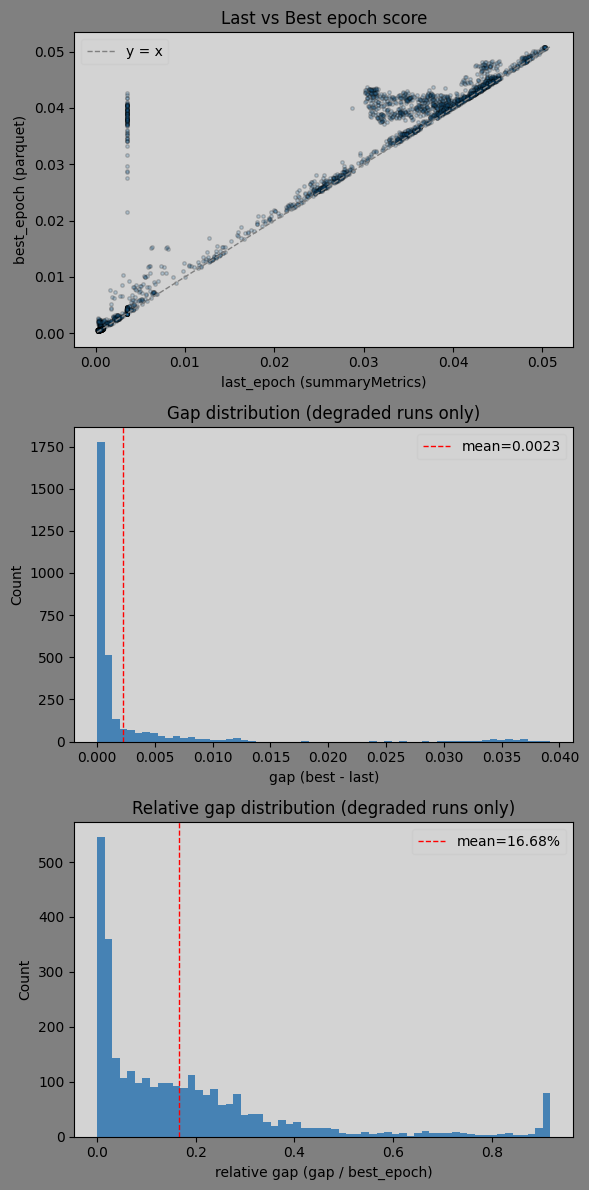

In [20]:
fig: Figure
axes: List[Axes]
fig, axes = plt.subplots(3, 1, figsize=(6, 12))

# 1. Scatter: last epoch vs best epoch
axes[0].scatter(last, best, alpha=0.2, s=6)
lo, hi = min(last.min(), best.min()), max(last.max(), best.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="grey", linewidth=1, label="y = x")
axes[0].set_xlabel("last_epoch (summaryMetrics)")
axes[0].set_ylabel("best_epoch (parquet)")
axes[0].set_title("Last vs Best epoch score")
axes[0].legend()

# 2. Gap distribution
axes[1].hist(gap[gap > 0], bins=60, color="steelblue")
axes[1].axvline(gap.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={gap.mean():.4f}")
axes[1].set_xlabel("gap (best - last)")
axes[1].set_ylabel("Count")
axes[1].set_title("Gap distribution (degraded runs only)")
axes[1].legend()

# 3. Gap as fraction of best score (relative bias)
rel_gap = gap / np.where(best > 0, best, np.nan)
axes[2].hist(rel_gap[np.isfinite(rel_gap) & (rel_gap > 0)], bins=60, color="steelblue")
axes[2].axvline(np.nanmean(rel_gap), color="red", linestyle="--", linewidth=1,
                label=f"mean={np.nanmean(rel_gap):.2%}")
axes[2].set_xlabel("relative gap (gap / best_epoch)")
axes[2].set_ylabel("Count")
axes[2].set_title("Relative gap distribution (degraded runs only)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Decision

**→ Use `best:epoch/test_recall@20` from `wandb/summary.parquet`.**

`summaryMetrics` (last-epoch) is not reliable as a surrogate training target:

- **93.6%** of runs are degraded at the last epoch vs. their best epoch
- **Mean relative gap: 16.68%** — the last-epoch value is on average ~17% below the peak for degraded runs
- The scatter plot shows a top-left cluster of runs that peaked at recall@20 ≈ 0.03–0.05 but collapsed to near-zero by the final epoch. Training the surrogate on these labels would corrupt the signal for genuinely good configurations.

**Requirement:** `wandb/sync.py` must be run with `--sorting_criterion epoch/test_recall@20` (or a composite that includes it) so that `best:epoch/test_recall@20` in the parquet reflects the true peak recall@20 per run.


In [22]:
pct_degraded   = 100 * (gap > 0).mean()
pct_large_gap  = 100 * (gap > 0.005).mean()
mean_rel_gap   = 100 * np.nanmean(rel_gap[np.isfinite(rel_gap)])

print("=" * 50)
print(f"  % runs degraded at last epoch:     {pct_degraded:.1f}%")
print(f"  % runs with gap > 0.005:           {pct_large_gap:.1f}%")
print(f"  mean relative gap (degraded only): {mean_rel_gap:.2f}%")
print("=" * 50)

if mean_rel_gap < 5 and pct_large_gap < 10:
    print("→ DECISION: summaryMetrics is reliable enough — proceed with live GraphQL approach")
else:
    print("→ DECISION: gap is significant — switch to reading wandb/summary.parquet")

  % runs degraded at last epoch:     93.6%
  % runs with gap > 0.005:           10.6%
  mean relative gap (degraded only): 16.68%
→ DECISION: gap is significant — switch to reading wandb/summary.parquet
